# Few-shot 학습 기반의 이미지 정합을 활용한 이상탐지

프로젝트 번호: 13

`소스코드 참고 사항`
- 학습시간이 너무 오래걸려 하이퍼 파라미터 수정: epoches 50-> 10, batch_size 32-> 64 로 변경

# 목차

1. 프로젝트 개요
	1. 프로젝트 연구 배경
    1. Few-Shot Anomaly Detection (FSAD)
    1. Registration
	1. STN(Spatial Transformer Network)
	1. Siamese Network + SimSiam
	1. 기대효과
1. 실습 환경 설정
	1. 엘리스 클라우드 가입
	1. 인스턴스 생성
	1. 인스턴스 삭제
    1. 인스턴스 SSH 접속
    1. 버전 확인
	1. 코드 업로드
    1. 패키지 설치
1. 데이터셋 준비
    1. 데이터셋 소개
    1. 깃허브 클론 및 데이터셋 다운로드
    1. 데이터셋 시각화
1. 모델 구축
    1. 코드 구성
    1. 모델 시각화
1. 코드 실행
	1. 모델 학습
	1. 모델 평가
1. 모델 실험 결과
    1. 논문 실험 결과
	1. 결과 분석
1. 결론
	1. 주요 업적
	1. 현장 실무에 유용할 주요 핵심 정리
	1. 기존 연구와의 차별점
	1. 기술적 한계
	1. 향후 연구 과제


# 프로젝트 개요

예상 모델 학습 소요시간:`90분`\
컴퓨팅 성능 요구: `낮음`\
논문: Chaoqin Huang, Haoyan Guan, Aofan Jiang, Ya Zhang, Michael Spratling, Yan-Feng Wang. Registration based Few-Shot Anomaly Detection.10.48550/arXiv.2207.07361\
소스코드 원본 주소: https://github.com/MediaBrain-SJTU/RegAD

## 프로젝트 연구 배경


- 제조분야에서 이상 탐지는 필수적
- 하지만 실제 현장에서는 정상 데이터만 존재하고 이상 데이터는 부족하거나 존재하지 않는 경우가 많음
- 전통적인 AD 방식
    - 범주마다 별도의 모델을 학습
    - 대부분 대량의 정상 이미지 필요
    - 새로운 범주 등장 시 모델 재학습 필수

## Registration 기반 Few-shot Anomaly Detection

<figure>
    <img src="image/RegAD_pipeline.png" width="1000"/>
    <figcaption>그림 1: RegAD 파이프라인<br>https://github.com/MediaBrain-SJTU/RegAD</figcaption>
</figure>

`Few-Shot Anomaly Detection (FSAD)`
- category마다 정상 정상 이미지가 소량(K-shot)만 존재
- 이상(Anomaly)데이터는 주어지지 않음
- 데이터의 공급이 한정적일 때 적은 수의 데이터로 넓은 범주의 이상 탐지

<figure>
    <img src="image/Anomaly_data_example.png" width="900"/>
    <figcaption>그림 2: 이상 데이터<br>https://www.mvtec.com</figcaption>
</figure>




`Registration(정합)`
- 두 이미지를 동일한 기준 좌표계로 정렬해서 비교하는 기술 (ex: CT/MRI 이미지 정합)
- 등록(registration)을 proxy task로 설정하여, 정렬된 특징(feature)을 비교하는 방식으로 anomaly 판별

<figure>
    <img src="image/MRI_Registration_example.png" width="900"/>
    <figcaption>그림 3: MRI 이미지 정합 예시<br>https://pebpung.github.io/registration/2022/01/30/Registration-1.html</figcaption>
</figure>


`STN(Spatial Transformer Network)`
- 입력 이미지나 feature map에 대해 회전, 이동, 스케일링 등 기하학적 변환을 학습적으로 적용
- 다양한 위치나 각도, 크기를 가진 물체들을 동일한 위치로 정렬
- RegAD에서는 ResNet의 layer1, 2, 3 출력에 각각 STN을 적용하여 점진적으로 정렬 성능 강화

<figure>
    <img src="image/STN_example.png" width="900"/>
    <figcaption>그림 4: Spatial Transformer Network<br>https://hwiyong.tistory.com/189</figcaption>
</figure>


`Siamese Network + SimSiam`
- Siamese
    - 두 입력 이미지를 각각 처리한 후, 출력 feature간의 유사도를 학습
    - RegAD에서는 정합된 feature간 Cosine similarity를 최대화 하도록 학습
- SimSiam
    - collapse방지를 위해 stop-gradient 사용
    - 하나의 branch만 학습하고, 나머지는 고정된 채로 비교

<figure>
    <img src="image/Siamese_example.png" width="900"/>
    <figcaption>그림 5: Siamese Network 예시<br>https://medium.com/@rinkinag24/a-comprehensive-guide-to-siamese-neural-networks-3358658c0513</figcaption>
</figure>


## 정합기반 Few-shot 이상탐지를 사용했을 때의 기대 효과

`Registration`
- 기존 FSAD는 단일 이미지의 정보만 활용하여 이상을 판단
- RegAD는 '정상 support 이미지와의 정렬(Registration)'을 통해 두 이미지간의 차이에 주목하여 anomaly 탐지
    - 범주 무관한 일반화 능력
        - 이미지 간 정합은 카테고리와 무관하게 적용 가능
        - 다양한 범주의 제품에 하나의 모델로 대응 가능
    - 사람의 시각적 비교 방식을 모방
    - 직관적인 anomaly 판단 가능

`STN`
- feature map을 자동으로 정렬하여 위치 불변성(spatial invariance)을 학습적으로 확보
    - 다양한 위치, 각도, 크기에 견고한 정렬
        - 실제 환경의 변형된 이미지에 강인함
    - 특징 간 비교 정밀도 향상
        - 잘 정렬된 feature간 비교로 anomaly 감지 정확도 상승
    - 실험적으로도 AUC 성능 향상
        - MVTec 기준 +2% 향상 (89.3 → 91.2), MPDD 기준 +7% 향상

`Siamese + SimSiam`
- 두 이미지 간 feature similarity를 학습하기 위한 Siamese + SimSiam 구조 채택
    - collapse 방지 및 안정적인 학습
        - SimSiam의 stop-gradient 구조 도입으로 representation quality 유지

# 실습 환경 설정

## 엘리스 클라우드 가입

1. 엘리스 클라우드 가입 시 사용할 이메일 주소로 초대장이 보내짐
1. 이메일을 열어 초대장 메일을 확인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/mail1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. "`학습지 가기`"를 클릭하여 로그인 화면으로 이동

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/mail2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 메일에 나와있는 이메일 아이디와 임시포스트를 입력하여 로그인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/login.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. 사용할 비밀번호를 입력하고 필수 동의사항에 동의 후 회원가입 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/login2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

6. 회원가입 완료

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/login3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 인스턴스 생성

1. 왼쪽 상단의 LXP를 클락한 뒤 클라우드를 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cloud.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 내 인스턴스 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cloud2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 인스턴스 생성을 클릭하여 생성 화면으로 이동

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cloud3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 인스턴스 유형으로 G-NAHP-80(A100 80GB PCle)을 선택

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. 인스턴스 이름 작성 후 실행 환경은 Jupyter 선택

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

6. 스토리지 옵션으로 `128`GB 선택
7. 이후 인스턴스 생성을 클릭해 생성을 완료

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

8. 이제 생성된 인스턴스에서 실습을 진행함
1. 이후 내 인스턴스 페이지로 돌아가기 위해 왼쪽 상단의 내 인스턴스 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 인스턴스 삭제

- 인스턴스 화면에 없어도 인스턴스는 계속 실행되고 있으므로 삭제 필요
- `사용이 끝난 경우 반드시 ‘종료’ 버튼을 눌러 실행을 중지해야 함`\
(단, 종료는 인스턴스에 여전히 필요한 데이터나 설정이 남아 있는 경우에만 사용)
- 인스턴스를 더 이상 사용할 일이 없다면, ‘삭제’를 통해 완전히 제거해야함
- 삭제는 반드시 인스턴스가 종료된 상태에서만 가능하며, 한 번 삭제하면 복구할 수 없음

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/instance5.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 인스턴스 접속(SSH)

### PEM 다운로드

> 주의: 한번 다운로드 받은 PEM 파일은 잘 보관해야 함\
> 재 발급 받은 경우 키 값이 달라지므로 재 발급 받은 파일로는 기존의 인스턴스에 접속 불가함\
> SSH 접속은 실습 환경에 필요한 모듈을 다운받는 등에 사용함

1. SSH 접속을 위해서는 비밀키 파일(PEM 파일)이 필요\
비밀키 발급하기 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. SSH 접속을 위해서는 비밀키 파일(PEM 파일) 필요\
PEM 파일 다운로드하기를 클릭하여 PEM 파일 저장

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### Command Prompt(혹은 Powershell) 실행

1. 윈도우(<span style="font-family: 'Wingdings';">&#xFF;</span>)  + R 키를 누르기
1. cmd 입력 (또는 powershell 입력)
1. Enter키 눌러서 Command Prompt 실행

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. "`cd [PEM파일 폴더 경로]`" 명령어를 사용하여 PEM 파일이 있는 위치로 이동\
예시: `cd %userprofile%\Downloads`\
(PEM 저장 위치 예시: 다운로드 폴더, 바탕화면, USB 등...)

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/key4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### SSH 접속 명령어

1. 내 인스턴스 페이지에서 다른 SSH 클라이언트 사용 선택

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 빠른 연결칸의 명령어를 복사

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 복사한 명령어를 앞서 실행한 powershell 또는 cmd에 붙여넣기

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. SSH 접속 완료, SSH 접속 창은 계속 사용 되므로 창을 닫지 않음

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/ssh4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 버전 확인

### 논문에서 구성한 버전 정보

- python >= 3.7.11
- pytorch >= 1.11.0
- torchvision >= 0.12.0
- numpy >= 1.19.5
- scipy >= 1.7.3
- skimage >= 0.19.2
- matplotlib >= 3.5.2
- kornia >= 0.6.5
- tqdm

### 파이썬 버전 확인

주피터 노트북에서 아래 명령어를 입력하여 확인하며 `엘리스 클라우드`의 주피터 노트북에 접속하여 입력함
> Tip: 파이썬 버전에 따라 텐서플로우 설치 가능 버전이 달라짐

1. 내 인스턴스에서 연결을 클릭하여 Jupyter notebook에 접속

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 우측 상단 `new` 버튼 클릭후 `Python 3(ipykernel)` 버튼 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 코드를 작성하여 파이썬 버전을 확인

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

In [ ]:
import sys
print('Python version', sys.version)

## 코드 업로드

### 주피터 노트북 웹 페이지에서 바로 업로드 하기

1. 내 인스턴스에서 연결을 클릭하여 Jupyter notebook에 접속

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/version.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 좌측 상단에 있는 `Upload` 버튼 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. 열기 대화창이 뜨면 다운 받은 주피터노트북 교육자료 파일(*.jpynb) 선택 후 `열기(O)` 클릭

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 파란색 `Upload` 버튼을 클릭하여 엘리스 클라우드 서버로 파일 업로드

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. 업로드한 교육자료 파일을 클릭하여 파일 열기

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload4.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

6. 강사의 지도에 따라 교육 자료를 활용합니다.

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/upload5.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

## 패키지 설치

### Miniconda 설치

> 원할하게 다양한 실습환경을 구축하기 위해 Miniconda의 가상환경을 생성하여 실습을 진행

SSH접속 후 아래의 명령어를 순차적으로 실행
- wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
- bash Miniconda3-latest-Linux-x86_64.sh
- source ~/.bashrc

1. 명령어 작성 예시

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. Please, press Enter to continue가 나오면 Enter 키를 누른 후 Page Down 키를 눌러 가장 아래로 내려감

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. Do you accept the license terms? [yes/no]가 나오며 yes 입력 후 Enter 키를 눌러 넘어감

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda2-1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. You can undo this by running 'conda init --reverse $SHELL'? [yes/no]가 나오면 yes를 입력하여 Miniconda 설치 완료

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda2-2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. Miniconda 설치 완료\
source ~/.bashrc 를 입력하여 변경 사항을 적용

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/miniconda3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### Conda 가상환경 생성 및 활성화

1. SSH에 가상환경 생성 명령어 작성
- conda create -n RegAD python=3.7.16
> conda create -n `가상환경 이름` python=`파이썬 버전`\

<figure>
    <img src="image/conda_python_version.png" width="900">
    <figcaption>가상환경 생성 명령어 작성 예시</figcaption>
</figure>

### Jupyter Notebook과 가상환경 연동

1. ipykernel 설치
- pip install ipykernel

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/CondaEnv3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. Jupyter Notebook에서 이 가상환경을 선택 가능한 커널로 등록
- python -m ipykernel install --user --name=`가상환경 이름` --display-name "`Jupyter에서 보여지는 이름`"

- python -m ipykernel install --user --name= RegAD --display-name "Python 3.7 (conda)"

<figure>
    <img src="image/ipykernel_name.png" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. 가상 환경 실행
- conda activate py38test
> conda activate `가상환경 이름`

<figure>
    <img src="image/conda_RegAD_activate.png" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. Jupyter Notebook에서 python3.7 버전으로 notebook 생성 가능

<figure>
    <img src="image/jupyter_kernel_name.png" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

4. 기존에 생성된 notebook에서 커널 변경 가능

<figure>
    <img src="image/jupyter_kernel_change.png" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

5. python 버전이 정상적으로 변경 되었는지 확인

<figure>
    <img src="image/python_check.png" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

In [ ]:
import sys
print('Python version', sys.version)

Python version 3.7.16 (default, Jan 17 2023, 22:20:44) 
[GCC 11.2.0]


### CUDA 설정

1. 패키지 관리자 업데이트
- sudo apt-get update
<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cuda1.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

2. CUDA Toolkit 설치
- 요구사항에 pytorch 버전이 1.11.0이기 때문에 이에 호환하는 CUDA 11.8 버전을 설치합니다.
- sudo apt-get install -y cuda-toolkit-11-8

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cuda2.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

3. cuDNN 설치
- sudo apt-get install -y libcudnn9-cuda-11

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/cuda3.png?raw=true" width="900">
    <!-- <figcaption></figcaption> -->
</figure>

### GPU 확인

NVIDIA 드라이버 확인

In [ ]:
!nvidia-smi

Mon Apr  7 02:53:42 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.06             Driver Version: 535.183.06   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A100 80GB PCIe          On  | 00000000:17:00.0 Off |                    0 |
| N/A   28C    P0              41W / 300W |      0MiB / 81920MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

CUDA 버전 확인

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:33:58_PDT_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0


cuDNN 버전 확인

In [ ]:
print(torch.backends.cudnn.version())

8200


### 필요한 라이브러리

`요구 사항`
- python >= 3.7.11
- pytorch >= 1.11.0
- torchvision >= 0.12.0
- numpy >= 1.19.5
- scipy >= 1.7.3
- skimage >= 0.19.2
- matplotlib >= 3.5.2
- kornia >= 0.6.5
- tqdm

### 패키지 버전 및 설치 확인

`필요 라이브러리 설치 명령어`

PyTorch 및 TorchVision 설치

가상 환경이 활성화된 SSH에 다음 명령어 입력
- pip install torch==1.11.0+cu113 torchvision==0.12.0+cu113 -f https://download.pytorch.org/whl/torch_stable.html

나머지 필요 라이브러리 설치

가상 환경이 활성화된 SSH에 다음 명령어 입력
- pip install pandas numpy==1.19.5 scipy matplotlib kornia tqdm scikit-learn ipython skimage

`주피터 노트북 환경에서 패키지 설치 여부 및 버전 확인`
- 아래 코드를 ssh에서 실행시켜 확인하고 없는 모듈 pip install 명령으로 다운로드
- 모두 설치가 완료되었다면 각 라이브러리의 버전 출력

In [ ]:
python -c "import sys, torch, torchvision, numpy, scipy, skimage, matplotlib, kornia, tqdm; \
print('Python:', sys.version); \
print('torch:', torch.__version__); \
print('torchvision:', torchvision.__version__); \
print('numpy:', numpy.__version__); \
print('scipy:', scipy.__version__); \
print('skimage:', skimage.__version__); \
print('matplotlib:', matplotlib.__version__); \
print('kornia:', kornia.__version__); \
print('tqdm:', tqdm.__version__)"

`Linux 환경에서 패키지 설치 여부 및 버전 확인(SSH 접속 필요)`
- pip list | grep `패키지_이름`
- conda list | grep `패키지_이름`

<figure>
    <img src="https://github.com/KDT-ai/Book-Image/blob/main/image/cloud/VersionCheck.png?raw=true" width="900">
    <figcaption>명령어 작성 예시</figcaption>
</figure>

> Tip: Windows는 grep 명령어 대신 findstr 명령어를 사용합니다.\
> %pip list | findstr `패키지_이름`\
> %conda list | findstr `패키지_이름`

---
# 데이터셋 준비

> 참고: 패키지 설치 이후 주피터 노트북 커널을 다시 시작하는 것이 좋습니다.

## 데이터셋 소개

`MVTec AD`
- 데이터셋 용량: 5.9GB (MVTec 4.9GB + support set 1.0GB)
- 15개 카테고리의 제품 종류 (ex: bottle, cable, transistor 등)
- 총 3629장의 train/validation 이미지 (정상 이미지만 포함)
- 총 1725장의 test 이미지 (정상 + 비정상 이미지 모두 포함)
- 평균적으로 각 카테고리당 5종의 불량 유형
- 총 73종의 결함 유형 존재
- 이미지 해상도: 700×700 ~ 1024×1024
- 픽셀 단위로 ground-truth 마스크 제공 → 정확한 이상 위치 판단 가능

`MPDD(Metal Parts Defect Dataset)`
    `*이 수업에서는 MPDD는 직접 실험해보지는 않음`
- 데이터셋 용량: 1.0GB
- 6개 클래스의 금속 부품
- 실제 공정 조건에서 수집됨
    - 다양한 위치, 방향, 거리
    - 다른 조명 조건
    - 비균질적 배경(non-homogeneous background)
- 결함은 도장 결함(painting defect) 중심


## 깃 허브 클론 및 데이터셋 다운로드


`논문 저자의 깃허브 주소 clone`

In [ ]:
!git clone https://github.com/MediaBrain-SJTU/RegAD.git
%cd RegAD

Cloning into 'RegAD'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 121 (delta 43), reused 41 (delta 41), pack-reused 70 (from 1)
Receiving objects: 100% (121/121), 7.22 MiB | 18.09 MiB/s, done.
Resolving deltas: 100% (61/61), done.
/home/elicer/RegAD


/home/elicer/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


`파일구조 구성`
- MVTec과 support_set 폴더 생성

<figure>
    <img src="image/File_structure.png" width="900">
    <figcaption>그림6: 파일구조<br>https://github.com/MediaBrain-SJTU/RegAD</figcaption>
</figure>

`MVTec 데이터셋 다운로드 및 압축 해제`

In [ ]:
# RegAD 폴더로 이동
!cd RegAD

# RegAD 폴더 내에 MVTec 디렉토리 생성 (추출 후 사용할 경로)
!mkdir -p MVTec

# MVTec-AD 데이터셋 다운로드 (압축 파일을 MVTec 폴더에 저장)
!wget https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/download/420938113-1629952094/mvtec_anomaly_detection.tar.xz -O MVTec/mvtec_ad.tar.xz

# 압축 해제 (압축 파일을 MVtec 폴더 안에 풀기)
!tar -xf MVTec/mvtec_ad.tar.xz -C MVTec/

--2025-04-04 09:41:54--  https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f282/download/420938113-1629952094/mvtec_anomaly_detection.tar.xz
Resolving www.mydrive.ch (www.mydrive.ch)... 91.214.169.64
Connecting to www.mydrive.ch (www.mydrive.ch)|91.214.169.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5264982680 (4.9G) [application/x-xz]
Saving to: ‘MVTec/mvtec_ad.tar.xz’

MVTec/mvtec_ad.tar. 100%[===================>]   4.90G  9.05MB/s    in 16m 17s 

2025-04-04 09:58:12 (5.14 MB/s) - ‘MVTec/mvtec_ad.tar.xz’ saved [5264982680/5264982680]



`support_set 직접 다운로드`

- https://drive.google.com/file/d/1AZcc77cmDfkWA8f8cs-j-CUuFFQ7tPoK/view
- 위 링크에서 support_set.tar 파일 다운로드
- jupyter notebook에 support_set.tar 파일 업로드 후 아래 코드 실행(압축 해제)

In [ ]:
# RegAD 폴더로 이동
!cd RegAD
#압축해제
!tar -xf support_set.tar 

## 데이터셋 시각화

아래 소스코드는 데이터셋에 있는데이터를 무작위로 6개 골라서 보여주는 코드

`데이터 시각화 환경 변수`

In [ ]:
image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.gif', '.JPG', '.PNG'] # 확장자 필터

`필요한 라이브러리`

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

`데이터셋 시각화 함수 정의`

In [ ]:
def dataset_image_sample_view(path):
	image_files = [
		f for f in os.listdir(path) # 해당 디렉토리 내 모든 파일 목록
		if any(f.endswith(ext) # 확장자 걸러내기
		for ext in image_extensions)] # 확장자 필터링 목록
	random_images = random.sample(image_files, 6) # 이미지 6개 무작위 선택

	fig, axes = plt.subplots(2, 3, figsize=(12, 8))  # 2행 3열 배열
	axes = axes.flatten() # 2차원 배열을 1차원 배열로 변경
	for i, img_file in enumerate(random_images): # 무작위로 뽑은 목록
		img_path = os.path.join(path, img_file) # 이미지 경로
		img = Image.open(img_path) # 이미지 읽어오기
		
		# 서브플롯에 이미지 표시
		axes[i].imshow(img) # 불러온 이미지 출력
		axes[i].axis('off')  # 축 숨기기
		axes[i].set_title(f"Image {i+1}")  # 제목 설정

	plt.tight_layout() # 여백 최소화
	plt.show() # 플롯(그래프) 보여주기

`MVTec dataset 시각화`

In [ ]:
dataset_image_sample_view(시각화할 이미지 폴더 경로 입력)

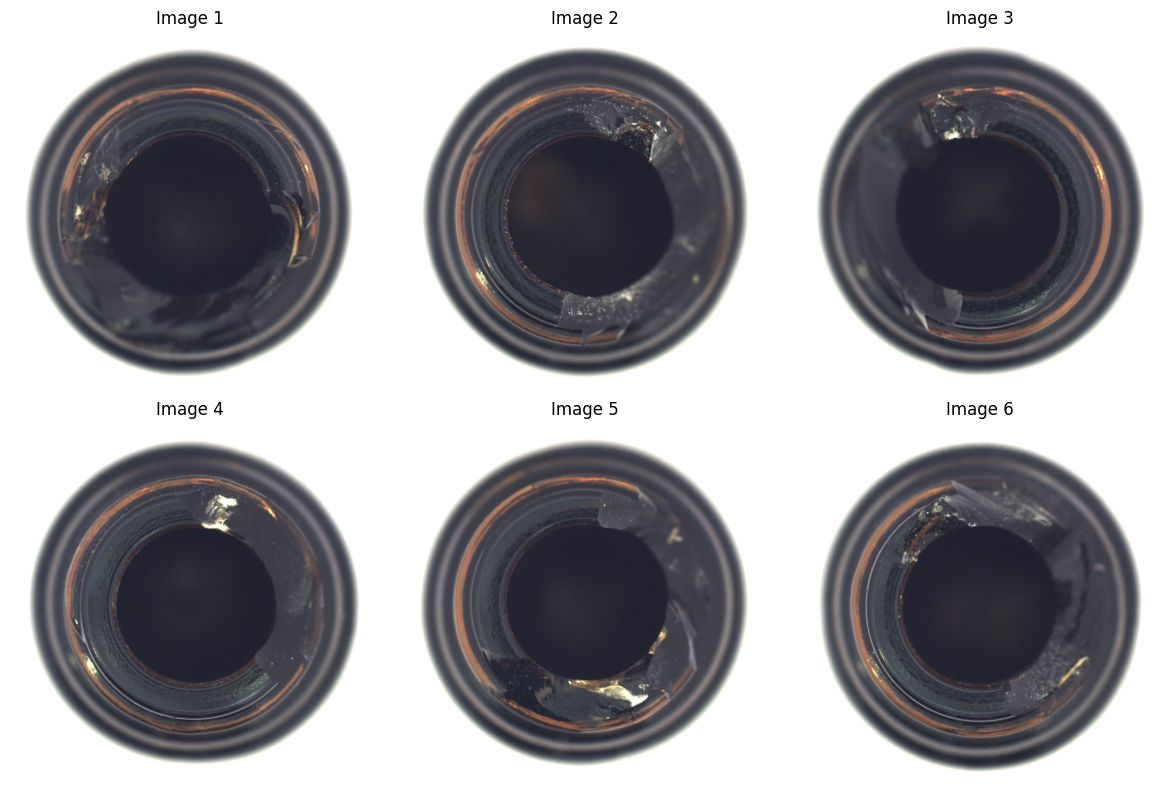

In [ ]:
dataset_image_sample_view('./MVTec/bottle/test/broken_large')

# 모델 구축

## 코드 구성

`/datasets/mvtec.py`
- Feature-level registration(정합)을 통해 정상 패턴을 모델이 일반화 학습하도록 함
- FASD_Dataset_train
    - 다양한 클래스 간 정상 이미지로 support-query 쌍 구성하여 모델 학습
- FASD_Dataset_test
    - 타깃 클래스에서 query 이미지를 가져오고, 정상 support와 비교하여 이상 여부 판단


In [ ]:
import os
from PIL import Image
import random
import math
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms

CLASS_NAMES = [
    'bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile',
    'toothbrush', 'transistor', 'wood', 'zipper'
]

class FSAD_Dataset_train(Dataset):
    def __init__(self,
                 dataset_path='../data/mvtec_anomaly_detection',
                 class_name='bottle',
                 is_train=True,
                 resize=256,
                 shot=2,
                 batch=32
                 ):
        assert class_name in CLASS_NAMES, 'class_name: {}, should be in {}'.format(class_name, CLASS_NAMES)
        self.dataset_path = dataset_path
        self.class_name = class_name
        self.is_train = is_train
        self.resize = resize
        self.shot = shot
        self.batch = batch
        # load dataset
        self.query_dir, self.support_dir = self.load_dataset_folder()
        # set transforms
        self.transform_x = transforms.Compose([
            transforms.Resize(resize, Image.Resampling.LANCZOS),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __getitem__(self, idx):
        query_list, support_list = self.query_dir[idx], self.support_dir[idx]
        query_img = None
        support_sub_img = None
        support_img = None

        for i in range(len(query_list)):
            image = Image.open(query_list[i]).convert('RGB')
            image = self.transform_x(image) #image_shape torch.Size([3, 224, 224])
            image = image.unsqueeze(dim=0) #image_shape torch.Size([1, 3, 224, 224])
            if query_img is None:
                query_img = image
            else:
                query_img = torch.cat([query_img, image],dim=0)

            for k in range(self.shot):
                image = Image.open(support_list[i][k]).convert('RGB')
                image = self.transform_x(image)
                image = image.unsqueeze(dim=0) #image_shape torch.Size([1, 3, 224, 224])
                if support_sub_img is None:
                    support_sub_img = image
                else:
                    support_sub_img = torch.cat([support_sub_img, image], dim=0)

            support_sub_img = support_sub_img.unsqueeze(dim=0)
            if support_img is None:
                support_img = support_sub_img
            else:
                support_img = torch.cat([support_img, support_sub_img], dim=0)

            support_sub_img = None

        mask = torch.zeros([self.batch, self.resize, self.resize])
        return query_img, support_img, mask

    def __len__(self):
        return len(self.query_dir)
    
    def shuffle_dataset(self):
        phase = 'train' if self.is_train else 'test'

        data_img = {}
        # data_img includes all image pathes, key: class_name like wood, zipper. value: each image path.
        for class_name_one in CLASS_NAMES:
            if class_name_one != self.class_name:
                data_img[class_name_one] = []
                img_dir = os.path.join(self.dataset_path, class_name_one, phase, 'good')
                img_types = sorted(os.listdir(img_dir))
                for img_type in img_types:
                    img_type_dir = os.path.join(img_dir, img_type)
                    data_img[class_name_one].append(img_type_dir)
                random.shuffle(data_img[class_name_one])

        query_dir, support_dir = [], []
        for class_name_one in data_img.keys():
            for image_index in range(0, len(data_img[class_name_one]), self.batch):
                query_sub_dir = []
                support_sub_dir = []
                for batch_count in range(0, self.batch):
                    if image_index + batch_count >= len(data_img[class_name_one]):
                        break
                    image_dir_one = data_img[class_name_one][image_index + batch_count]
                    support_dir_one = []
                    query_sub_dir.append(image_dir_one)
                    for k in range(self.shot):
                        random_choose = random.randint(0, (len(data_img[class_name_one]) - 1))
                        while data_img[class_name_one][random_choose] == image_dir_one:
                            random_choose = random.randint(0, (len(data_img[class_name_one]) - 1))
                        support_dir_one.append(data_img[class_name_one][random_choose])
                    support_sub_dir.append(support_dir_one)
                
                query_dir.append(query_sub_dir)
                support_dir.append(support_sub_dir)

        assert len(query_dir) == len(support_dir), 'number of query_dir and support_dir should be same'
        self.query_dir = query_dir
        self.support_dir = support_dir

    def load_dataset_folder(self):
        phase = 'train' if self.is_train else 'test'

        data_img = {}
        for class_name_one in CLASS_NAMES:
            if class_name_one != self.class_name:
                data_img[class_name_one] = []
                img_dir = os.path.join(self.dataset_path, class_name_one, phase, 'good')
                img_types = sorted(os.listdir(img_dir))
                for img_type in img_types:
                    img_type_dir = os.path.join(img_dir, img_type)
                    data_img[class_name_one].append(img_type_dir)
                random.shuffle(data_img[class_name_one])

        query_dir, support_dir = [], []
        for class_name_one in data_img.keys():

            for image_index in range(0, len(data_img[class_name_one]), self.batch):
                query_sub_dir = []
                support_sub_dir = []

                for batch_count in range(0, self.batch):
                    if image_index + batch_count >= len(data_img[class_name_one]):
                        break
                    image_dir_one = data_img[class_name_one][image_index + batch_count]
                    support_dir_one = []
                    query_sub_dir.append(image_dir_one)
                    for k in range(self.shot):
                        random_choose = random.randint(0, (len(data_img[class_name_one]) - 1))
                        while data_img[class_name_one][random_choose] == image_dir_one:
                            random_choose = random.randint(0, (len(data_img[class_name_one]) - 1))
                        support_dir_one.append(data_img[class_name_one][random_choose])
                    support_sub_dir.append(support_dir_one)
                
                query_dir.append(query_sub_dir)
                support_dir.append(support_sub_dir)

        assert len(query_dir) == len(support_dir), 'number of query_dir and support_dir should be same'
        return query_dir, support_dir


class FSAD_Dataset_test(Dataset):
    def __init__(self,
                 dataset_path='../data/mvtec_anomaly_detection',
                 class_name='bottle',
                 is_train=True,
                 resize=256,
                 shot=2
                 ):
        assert class_name in CLASS_NAMES, 'class_name: {}, should be in {}'.format(class_name, CLASS_NAMES)
        self.dataset_path = dataset_path
        self.class_name = class_name
        self.is_train = is_train
        self.resize = resize
        self.shot = shot
        # load dataset
        self.query_dir, self.support_dir, self.query_mask = self.load_dataset_folder()
        # set transforms
        self.transform_x = transforms.Compose([
            transforms.Resize(resize, Image.Resampling.LANCZOS),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.transform_mask = transforms.Compose(
            [transforms.Resize(resize, Image.NEAREST),
             transforms.ToTensor()])

    def __getitem__(self, idx):
        query_one, support_one, mask_one = self.query_dir[idx], self.support_dir[idx], self.query_mask[idx]
        query_img = Image.open(query_one).convert('RGB')
        query_img = self.transform_x(query_img)

        support_img = []
        for k in range(self.shot):
            support_img_one = Image.open(support_one[k]).convert('RGB')
            support_img_one = self.transform_x(support_img_one)
            support_img.append(support_img_one)

        if 'good' in mask_one:
            mask = torch.zeros([1, self.resize, self.resize])
            y = 0
        else:
            mask = Image.open(mask_one)
            mask = self.transform_mask(mask)
            y = 1
        return query_img, support_img, mask, y

    def __len__(self):
        return len(self.query_dir)

    def load_dataset_folder(self):
        phase = 'train' if self.is_train else 'test'
        query_dir, support_dir = [], []
        data_img = {}
        img_dir = os.path.join(self.dataset_path, self.class_name, phase)
        img_types = sorted(os.listdir(img_dir))
        for img_type in img_types:
            data_img[img_type] = []
            img_type_dir = os.path.join(img_dir, img_type)
            img_num = sorted(os.listdir(img_type_dir))
            for img_one in img_num:
                img_dir_one = os.path.join(img_type_dir, img_one)
                data_img[img_type].append(img_dir_one)
        img_dir_train = os.path.join(self.dataset_path, self.class_name, 'train', 'good')
        img_num = sorted(os.listdir(img_dir_train))

        data_train = []
        for img_one in img_num:
            img_dir_one = os.path.join(img_dir_train, img_one)
            data_train.append(img_dir_one)

        gt_dir = os.path.join(self.dataset_path, self.class_name, 'ground_truth')
        query_dir, support_dir, query_mask = [], [], []
        for img_type in data_img.keys():
            for image_dir_one in data_img[img_type]:
                support_dir_one = []
                query_dir.append(image_dir_one)
                query_mask_dir = image_dir_one.replace('test', 'ground_truth')
                query_mask_dir = query_mask_dir[:-4] + '_mask.png'
                query_mask.append(query_mask_dir)
                for k in range(self.shot):
                    random_choose = random.randint(0, (len(data_train) - 1))
                    support_dir_one.append(data_train[random_choose])
                support_dir.append(support_dir_one)

        assert len(query_dir) == len(support_dir) == len(
            query_mask), 'number of query_dir and support_dir should be same'
        return query_dir, support_dir, query_mask

`/losses/norm_loss.py`
- 거리기반(L2)과 방향 기반(Cosine) 정합 손실을 통해 모델이 support-query간 유사 feature를 더 정확히 매칭하도록 학습 유도함
- L2Loss
    - 두 feature 간 L2 거리(유클리디안 거리)를 평균내어 feature 차이를 정량화
- CosLoss
    - 두 feature 간 방향 유사성(Cosine similarity)을 기반으로 손실 계산하여 정합도 향상 유도

In [ ]:
import torch
from torch.functional import norm
import torch.nn.functional as F
import torch.nn as nn
from math import exp
from functools import partial


def L2Loss(data1, data2):
    # data shape: BCHW
    
    norm_data = torch.norm(data1-data2, p=2, dim=1)
    # norm_data shape: BHW

    loss = norm_data.mean()
    # print("loss: ", loss)
    return loss


def CosLoss(data1, data2, Mean=True):
    data2 = data2.detach()
    cos = nn.CosineSimilarity(dim=1)
    if Mean:
        return -cos(data1, data2).mean()
    else:
        return -cos(data1, data2)

`/models/siamese.py`
- 1x1 convolution을 반복 적용하여 feature 채널 간 관계를 강화하고, 정합에 유리한 표현 공간으로 압축하는 구조를 사용함
- Encoder
    - 입력 feature를 정제하고 embedding space로 매핑하기 위한 1x1 Conv 기반의 feature extractor
- Predictor
    - 임베딩된 feature를 변환(Projection)하여 query-support 간 정합 여부를 평가하기 위한 구성

In [ ]:
import torch
from typing import Type, Any, Callable, Union, List, Optional
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
from torchvision.models import resnet18

def conv3x3(in_planes: int, out_planes: int, stride: int = 1, groups: int = 1, dilation: int = 1) -> nn.Conv2d:
    """3x3 convolution with padding"""
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation,
    )


def conv1x1(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv1 = conv1x1(in_planes=256, out_planes=256)
        self.bn1 = nn.BatchNorm2d(256)
        self.relu1 = nn.ReLU()

        self.conv2 = conv1x1(in_planes=256, out_planes=256)
        self.bn2 = nn.BatchNorm2d(256)
        self.relu2 = nn.ReLU()

        self.conv3 = conv1x1(in_planes=256, out_planes=256)
        self.bn3 = nn.BatchNorm2d(256)
        self.relu3 = nn.ReLU()
    
    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        out = self.conv3(x)
        # out = self.relu3(x)

        return out



class Predictor(nn.Module):
    def __init__(self):
        super(Predictor, self).__init__()
        self.conv1 = conv1x1(in_planes=256, out_planes=256)
        self.bn1 = nn.BatchNorm2d(256)
        self.relu1 = nn.ReLU()

        self.conv2 = conv1x1(in_planes=256, out_planes=256)
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        out = self.conv2(x)
        # out = self.relu2(x)

        return out

`/models/stn.py`
- STNModule을 각 단계에 삽입하여 Feature-level에서 공간 정합 보정 수행, 이를 통해 query-support 간 비교가 보다 정밀해지며, anomaly localization 성능 향상에 기여함.
- STMModule
    - 입력 feature map에 대해 회전, 이동, 스케일 등의 변환 파라미터(θ)를 학습하고, 그에 따른 Affine 변환을 적용
- BasicBlock
    - ResNet의 기본 residual block 구성. skip connection 구조로 학습 안정성 향상
- ResNet
    - layer1~3을 거치며 점진적으로 추상화된 feature 추출 + 각 레이어 이후 STNModule을 통해 geometric 보정
- stn_net()
    - ResNet18 구조 기반으로 STN이 삽입된 모델 생성. ImageNet pretrained weight 로드 가능

In [ ]:
import torch
from typing import Type, Any, Callable, Union, List, Optional
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
from torchvision.models import resnet18
import torch.utils.model_zoo as model_zoo
from torch.autograd import Variable
import numpy as np

model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
}

N_PARAMS = {'affine': 6,
            'translation': 2,
            'rotation': 1,
            'scale': 2,
            'shear': 2,
            'rotation_scale': 3,
            'translation_scale': 4,
            'rotation_translation': 3,
            'rotation_translation_scale': 5}


def conv3x3(in_planes: int, out_planes: int, stride: int = 1, groups: int = 1, dilation: int = 1) -> nn.Conv2d:
    """3x3 convolution with padding"""
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation,
    )


def conv1x1(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

class STNModule(nn.Module):
    def __init__(self, in_num, block_index, args):
        super(STNModule, self).__init__()

        self.feat_size = 56 // (4 * block_index)
        self.stn_mode = args.stn_mode
        self.stn_n_params = N_PARAMS[self.stn_mode]

        self.conv = nn.Sequential(
            conv3x3(in_planes=in_num, out_planes=64),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            conv3x3(in_planes=64, out_planes=16),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.fc = nn.Sequential(
            nn.Linear(in_features=16 * self.feat_size * self.feat_size, out_features=1024),
            nn.ReLU(True),
            nn.Linear(in_features=1024, out_features=self.stn_n_params),
        )
        self.fc[2].weight.data.fill_(0)
        self.fc[2].weight.data.zero_()

        if self.stn_mode == 'affine':
            self.fc[2].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))
        elif self.stn_mode in ['translation', 'shear']:
            self.fc[2].bias.data.copy_(torch.tensor([0, 0], dtype=torch.float))
        elif self.stn_mode == 'scale':
            self.fc[2].bias.data.copy_(torch.tensor([1, 1], dtype=torch.float))
        elif self.stn_mode == 'rotation':
            self.fc[2].bias.data.copy_(torch.tensor([0], dtype=torch.float))
        elif self.stn_mode == 'rotation_scale':
            self.fc[2].bias.data.copy_(torch.tensor([0, 1, 1], dtype=torch.float))
        elif self.stn_mode == 'translation_scale':
            self.fc[2].bias.data.copy_(torch.tensor([0, 0, 1, 1], dtype=torch.float))
        elif self.stn_mode == 'rotation_translation':
            self.fc[2].bias.data.copy_(torch.tensor([0, 0, 0], dtype=torch.float))
        elif self.stn_mode == 'rotation_translation_scale':
            self.fc[2].bias.data.copy_(torch.tensor([0, 0, 0, 1, 1], dtype=torch.float))

    def forward(self, x):
        mode = self.stn_mode
        batch_size = x.size(0)
        conv_x = self.conv(x)
        theta = self.fc(conv_x.view(batch_size, -1))

        if mode == 'affine':
            theta1 = theta.view(batch_size, 2, 3)
        else:
            theta1 = Variable(torch.zeros([batch_size, 2, 3], dtype=torch.float32, device=x.get_device()),
                              requires_grad=True)
            theta1 = theta1 + 0
            theta1[:, 0, 0] = 1.0
            theta1[:, 1, 1] = 1.0
            if mode == 'translation':
                theta1[:, 0, 2] = theta[:, 0]
                theta1[:, 1, 2] = theta[:, 1]
            elif mode == 'rotation':
                angle = theta[:, 0]
                theta1[:, 0, 0] = torch.cos(angle)
                theta1[:, 0, 1] = -torch.sin(angle)
                theta1[:, 1, 0] = torch.sin(angle)
                theta1[:, 1, 1] = torch.cos(angle)
            elif mode == 'scale':
                theta1[:, 0, 0] = theta[:, 0]
                theta1[:, 1, 1] = theta[:, 1]
            elif mode == 'shear':
                theta1[:, 0, 1] = theta[:, 0]
                theta1[:, 1, 0] = theta[:, 1]
            elif mode == 'rotation_scale':
                angle = theta[:, 0]
                theta1[:, 0, 0] = torch.cos(angle) * theta[:, 1]
                theta1[:, 0, 1] = -torch.sin(angle)
                theta1[:, 1, 0] = torch.sin(angle)
                theta1[:, 1, 1] = torch.cos(angle) * theta[:, 2]
            elif mode == 'translation_scale':
                theta1[:, 0, 2] = theta[:, 0]
                theta1[:, 1, 2] = theta[:, 1]
                theta1[:, 0, 0] = theta[:, 2]
                theta1[:, 1, 1] = theta[:, 3]
            elif mode == 'rotation_translation':
                angle = theta[:, 0]
                theta1[:, 0, 0] = torch.cos(angle)
                theta1[:, 0, 1] = -torch.sin(angle)
                theta1[:, 1, 0] = torch.sin(angle)
                theta1[:, 1, 1] = torch.cos(angle)
                theta1[:, 0, 2] = theta[:, 1]
                theta1[:, 1, 2] = theta[:, 2]
            elif mode == 'rotation_translation_scale':
                angle = theta[:, 0]
                theta1[:, 0, 0] = torch.cos(angle) * theta[:, 3]
                theta1[:, 0, 1] = -torch.sin(angle)
                theta1[:, 1, 0] = torch.sin(angle)
                theta1[:, 1, 1] = torch.cos(angle) * theta[:, 4]
                theta1[:, 0, 2] = theta[:, 1]
                theta1[:, 1, 2] = theta[:, 2]

        grid = F.affine_grid(theta1, torch.Size(x.shape))
        img_transform = F.grid_sample(x, grid, padding_mode="reflection")

        return img_transform, theta1


class BasicBlock(nn.Module):
    expansion: int = 1

    def __init__(
            self,
            inplanes: int,
            planes: int,
            stride: int = 1,
            downsample: Optional[nn.Module] = None,
            groups: int = 1,
            base_width: int = 64,
            dilation: int = 1,
            norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock only supports groups=1 and base_width=64")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self, args, block, layers):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.stn1 = STNModule(64, 1, args)

        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.stn2 = STNModule(128, 2, args)

        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.stn3 = STNModule(256, 3, args)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def _fixstn(self, x, theta):
        grid = F.affine_grid(theta, torch.Size(x.shape))
        img_transform = F.grid_sample(x, grid, padding_mode="reflection")

        return img_transform

    def forward(self, x: Tensor) -> Tensor:
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        # torch.Size([32, 64, 56, 56])

        x = self.layer1(x)
        x, theta1 = self.stn1(x)
        tmp = np.tile(np.array([0, 0, 1]), (x.shape[0], 1, 1)).astype(np.float32)
        fixthea1 = torch.from_numpy(np.linalg.inv(np.concatenate((theta1.detach().cpu().numpy(), tmp), axis=1))[:,:-1,:]).cuda()

        self.stn1_output = self._fixstn(x.detach(), fixthea1)
        # after layer1 shape:  torch.Size([32, 64, 56, 56])

        x = self.layer2(x)
        x, theta2 = self.stn2(x)
        tmp = np.tile(np.array([0, 0, 1]), (x.shape[0], 1, 1)).astype(np.float32)
        fixthea2 = torch.from_numpy(np.linalg.inv(np.concatenate((theta2.detach().cpu().numpy(), tmp), axis=1))[:,:-1,:]).cuda()
        self.stn2_output = self._fixstn(self._fixstn(x.detach(), fixthea2), fixthea1)
        # after layer2 shape:  torch.Size([32, 128, 28, 28])

        x = self.layer3(x)
        out, theta3 = self.stn3(x)
        tmp = np.tile(np.array([0, 0, 1]), (x.shape[0], 1, 1)).astype(np.float32)
        fixthea3 = torch.from_numpy(np.linalg.inv(np.concatenate((theta3.detach().cpu().numpy(), tmp), axis=1))[:,:-1,:]).cuda()
        self.stn3_output = self._fixstn(self._fixstn(self._fixstn(out.detach(), fixthea3), fixthea2), fixthea1)
        # after layer3 shape:  torch.Size([32, 256, 14, 14])

        return out


def stn_net(args, pretrained=True, **kwargs):
    """Constructs a ResNet-18 model.
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
    """
    model = ResNet(args, BasicBlock, [2, 2, 2, 2], **kwargs)
    if pretrained:
        model.load_state_dict(model_zoo.load_url(model_urls['resnet18']), strict=False)
    return model

`/RegAD/train.py`
- Support-query 간 정합을 Cosine 유사도로 학습하고,STN으로 정렬된 Feature에 대해 Mahalanobis 거리 기반 anomaly score를 계산함. Support-set은 회전·이동·흑백 등 다양한 증강을 거쳐 모델 일반화 및 localization 성능을 향상시킴.
- main()
    - 하이퍼파라미터 설정 → 모델/데이터셋 로드 → 학습 및 테스트 루프 실행
- train()
    - query-support 이미지 쌍을 입력받아 Siamese 구조로 학습 진행 Cosine 유사도 기반 쌍별 손실(CosLoss) 계산
- test()
    - 다양한 증강 적용된 support 이미지로부터 feature 평균 생성 → query와 비교하여 이상 점수 계산 및 AUC 평가
- adjust_learning_rate()
    - Cosine Annealing 방식으로 learning rate 조정하여 안정적 수렴 유도

In [ ]:
import os
import random
import argparse
import time
import math
import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from datasets.mvtec import FSAD_Dataset_train, FSAD_Dataset_test
from utils.utils import time_file_str, time_string, convert_secs2time, AverageMeter, print_log
from models.siamese import Encoder, Predictor
from models.stn import stn_net
from losses.norm_loss import CosLoss
from utils.funcs import embedding_concat, mahalanobis_torch, rot_img, translation_img, hflip_img, rot90_img, grey_img
from sklearn.metrics import roc_auc_score
from scipy.ndimage import gaussian_filter
from collections import OrderedDict
import warnings
warnings.filterwarnings("ignore")
use_cuda = torch.cuda.is_available()
device = torch.device('cuda' if use_cuda else 'cpu')

def main():
    parser = argparse.ArgumentParser(description='Registration based Few-Shot Anomaly Detection')
    parser.add_argument('--obj', type=str, default='bottle')
    parser.add_argument('--data_type', type=str, default='mvtec')
    parser.add_argument('--data_path', type=str, default='./MVTec/')
    parser.add_argument('--epochs', type=int, default=50, help='maximum training epochs')
    parser.add_argument('--batch_size', type=int, default=32)
    parser.add_argument('--img_size', type=int, default=224)
    parser.add_argument('--lr', type=float, default=0.0001, help='learning rate of others in SGD')
    parser.add_argument('--momentum', type=float, default=0.9, help='momentum of SGD')
    parser.add_argument('--seed', type=int, default=668, help='manual seed')
    parser.add_argument('--shot', type=int, default=2, help='shot count')
    parser.add_argument('--inferences', type=int, default=10, help='number of rounds per inference')
    parser.add_argument('--stn_mode', type=str, default='rotation_scale',
                        help='[affine, translation, rotation, scale, shear, rotation_scale, translation_scale, rotation_translation, rotation_translation_scale]')
    args = parser.parse_args()
    args.input_channel = 3

    if args.seed is None:
        args.seed = random.randint(1, 10000)
        random.seed(args.seed)
        torch.manual_seed(args.seed)
    if use_cuda:
        torch.cuda.manual_seed_all(args.seed)

    args.prefix = time_file_str()
    args.save_dir = './logs_mvtec/'
    if not os.path.exists(args.save_dir):
        os.makedirs(args.save_dir)

    args.save_model_dir = './logs_mvtec/' + args.stn_mode + '/' + str(args.shot) + '/' + args.obj + '/'
    if not os.path.exists(args.save_model_dir):
        os.makedirs(args.save_model_dir)

    log = open(os.path.join(args.save_dir, 'log_{}_{}.txt'.format(str(args.shot),args.obj)), 'w')
    state = {k: v for k, v in args._get_kwargs()}
    print_log(state, log)

    # load model and dataset
    STN = stn_net(args).to(device)
    ENC = Encoder().to(device)
    PRED = Predictor().to(device)

    print(STN)

    STN_optimizer = optim.SGD(STN.parameters(), lr=args.lr, momentum=args.momentum)
    ENC_optimizer = optim.SGD(ENC.parameters(), lr=args.lr, momentum=args.momentum)
    PRED_optimizer = optim.SGD(PRED.parameters(), lr=args.lr, momentum=args.momentum)
    models = [STN, ENC, PRED]
    optimizers = [STN_optimizer, ENC_optimizer, PRED_optimizer]
    init_lrs = [args.lr, args.lr, args.lr]

    print('Loading Datasets')
    kwargs = {'num_workers': 4, 'pin_memory': True} if use_cuda else {}
    train_dataset = FSAD_Dataset_train(args.data_path, class_name=args.obj, is_train=True, resize=args.img_size, shot=args.shot, batch=args.batch_size)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=True, **kwargs)
    test_dataset = FSAD_Dataset_test(args.data_path, class_name=args.obj, is_train=False, resize=args.img_size, shot=args.shot)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, **kwargs)

    # start training
    save_name = os.path.join(args.save_model_dir, '{}_{}_{}_model.pt'.format(args.obj, args.shot, args.stn_mode))
    start_time = time.time()
    epoch_time = AverageMeter()
    img_roc_auc_old = 0.0
    per_pixel_rocauc_old = 0.0
    print('Loading Fixed Support Set')
    fixed_fewshot_list = torch.load(f'./support_set/{args.obj}/{args.shot}_{args.inferences}.pt')
    print_log((f'---------{args.stn_mode}--------'), log)

    for epoch in range(1, args.epochs + 1):
        adjust_learning_rate(optimizers, init_lrs, epoch, args)
        need_hour, need_mins, need_secs = convert_secs2time(epoch_time.avg * (args.epochs - epoch))
        need_time = '[Need: {:02d}:{:02d}:{:02d}]'.format(need_hour, need_mins, need_secs)
        print_log(' {:3d}/{:3d} ----- [{:s}] {:s}'.format(epoch, args.epochs, time_string(), need_time), log)

        if epoch <= args.epochs:
            image_auc_list = []
            pixel_auc_list = []
            for inference_round in tqdm(range(args.inferences)):
                scores_list, test_imgs, gt_list, gt_mask_list = test(models, inference_round, fixed_fewshot_list,
                                                                     test_loader, **kwargs)
                scores = np.asarray(scores_list)
                # Normalization
                max_anomaly_score = scores.max()
                min_anomaly_score = scores.min()
                scores = (scores - min_anomaly_score) / (max_anomaly_score - min_anomaly_score)

                # calculate image-level ROC AUC score
                img_scores = scores.reshape(scores.shape[0], -1).max(axis=1)
                gt_list = np.asarray(gt_list)
                img_roc_auc = roc_auc_score(gt_list, img_scores)
                image_auc_list.append(img_roc_auc)

                # calculate per-pixel level ROCAUC
                gt_mask = np.asarray(gt_mask_list)
                gt_mask = (gt_mask > 0.5).astype(np.int_)
                per_pixel_rocauc = roc_auc_score(gt_mask.flatten(), scores.flatten())
                pixel_auc_list.append(per_pixel_rocauc)

            image_auc_list = np.array(image_auc_list)
            pixel_auc_list = np.array(pixel_auc_list)
            mean_img_auc = np.mean(image_auc_list, axis = 0)
            mean_pixel_auc = np.mean(pixel_auc_list, axis = 0)

            if mean_img_auc + mean_pixel_auc > per_pixel_rocauc_old + img_roc_auc_old:
                state = {'STN': STN.state_dict(), 'ENC': ENC.state_dict(), 'PRED':PRED.state_dict()}
                torch.save(state, save_name)
                per_pixel_rocauc_old = mean_pixel_auc
                img_roc_auc_old = mean_img_auc
            print('Img-level AUC:',img_roc_auc_old)
            print('Pixel-level AUC:', per_pixel_rocauc_old)

            print_log(('Test Epoch(img, pixel): {} ({:.6f}, {:.6f}) best: ({:.3f}, {:.3f})'
            .format(epoch-1, mean_img_auc, mean_pixel_auc, img_roc_auc_old, per_pixel_rocauc_old)), log)

        epoch_time.update(time.time() - start_time)
        start_time = time.time()
        train(models, epoch, train_loader, optimizers, log)
        train_dataset.shuffle_dataset()
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=True, **kwargs)
        
    log.close()

def train(models, epoch, train_loader, optimizers, log):
    STN = models[0]
    ENC = models[1]
    PRED = models[2]

    STN_optimizer = optimizers[0]
    ENC_optimizer = optimizers[1]
    PRED_optimizer = optimizers[2]

    STN.train()
    ENC.train()
    PRED.train()

    total_losses = AverageMeter()

    for (query_img, support_img_list, _) in tqdm(train_loader):
        STN_optimizer.zero_grad()
        ENC_optimizer.zero_grad()
        PRED_optimizer.zero_grad()

        query_img = query_img.squeeze(0).to(device)
        query_feat = STN(query_img)
        support_img = support_img_list.squeeze(0).to(device)
        B,K,C,H,W = support_img.shape

        support_img = support_img.view(B * K, C, H, W)
        support_feat = STN(support_img)
        support_feat = support_feat / K

        _, C, H, W = support_feat.shape
        support_feat = support_feat.view(B, K, C, H, W)
        support_feat = torch.sum(support_feat, dim=1)

        z1 = ENC(query_feat)
        z2 = ENC(support_feat)
        p1 = PRED(z1)
        p2 = PRED(z2)
        total_loss = CosLoss(p1,z2, Mean=True)/2 + CosLoss(p2,z1, Mean=True)/2
        total_losses.update(total_loss.item(), query_img.size(0))

        total_loss.backward()

        STN_optimizer.step()
        ENC_optimizer.step()
        PRED_optimizer.step()

    print_log(('Train Epoch: {} Total_Loss: {:.6f}'.format(epoch, total_losses.avg)), log)


def test(models, cur_epoch, fixed_fewshot_list, test_loader, **kwargs):
    STN = models[0]
    ENC = models[1]
    PRED = models[2]

    STN.eval()
    ENC.eval()
    PRED.eval()

    train_outputs = OrderedDict([('layer1', []), ('layer2', []), ('layer3', [])])
    test_outputs = OrderedDict([('layer1', []), ('layer2', []), ('layer3', [])])

    support_img = fixed_fewshot_list[cur_epoch]
    augment_support_img = support_img
    # rotate img with small angle
    for angle in [-np.pi / 4, -3 * np.pi / 16, -np.pi / 8, -np.pi / 16, np.pi / 16, np.pi / 8, 3 * np.pi / 16,
                  np.pi / 4]:
        rotate_img = rot_img(support_img, angle)
        augment_support_img = torch.cat([augment_support_img, rotate_img], dim=0)
    # translate img
    for a, b in [(0.2, 0.2), (-0.2, 0.2), (-0.2, -0.2), (0.2, -0.2), (0.1, 0.1), (-0.1, 0.1), (-0.1, -0.1),
                 (0.1, -0.1)]:
        trans_img = translation_img(support_img, a, b)
        augment_support_img = torch.cat([augment_support_img, trans_img], dim=0)
    # hflip img
    flipped_img = hflip_img(support_img)
    augment_support_img = torch.cat([augment_support_img, flipped_img], dim=0)
    # rgb to grey img
    greyed_img = grey_img(support_img)
    augment_support_img = torch.cat([augment_support_img, greyed_img], dim=0)
    # rotate img in 90 degree
    for angle in [1, 2, 3]:
        rotate90_img = rot90_img(support_img, angle)
        augment_support_img = torch.cat([augment_support_img, rotate90_img], dim=0)
    augment_support_img = augment_support_img[torch.randperm(augment_support_img.size(0))]

    # torch version
    with torch.no_grad():
        support_feat = STN(augment_support_img.to(device))
    support_feat = torch.mean(support_feat, dim=0, keepdim=True)
    train_outputs['layer1'].append(STN.stn1_output)
    train_outputs['layer2'].append(STN.stn2_output)
    train_outputs['layer3'].append(STN.stn3_output)

    for k, v in train_outputs.items():
        train_outputs[k] = torch.cat(v, 0)

    # Embedding concat
    embedding_vectors = train_outputs['layer1']
    for layer_name in ['layer2', 'layer3']:
        embedding_vectors = embedding_concat(embedding_vectors, train_outputs[layer_name], True)

    # calculate multivariate Gaussian distribution
    B, C, H, W = embedding_vectors.size()
    embedding_vectors = embedding_vectors.view(B, C, H * W)
    mean = torch.mean(embedding_vectors, dim=0)
    cov = torch.zeros(C, C, H * W).to(device)
    I = torch.eye(C).to(device)
    for i in range(H * W):
        cov[:, :, i] = torch.cov(embedding_vectors[:, :, i].T) + 0.01 * I
    train_outputs = [mean, cov]

    # torch version
    query_imgs = []
    gt_list = []
    mask_list = []
    score_map_list = []

    for (query_img, _, mask, y) in test_loader:
        query_imgs.extend(query_img.cpu().detach().numpy())
        gt_list.extend(y.cpu().detach().numpy())
        mask_list.extend(mask.cpu().detach().numpy())

        # model prediction
        query_feat = STN(query_img.to(device))
        z1 = ENC(query_feat)
        z2 = ENC(support_feat)
        p1 = PRED(z1)
        p2 = PRED(z2)

        loss = CosLoss(p1, z2, Mean=False) / 2 + CosLoss(p2, z1, Mean=False) / 2
        loss_reshape = F.interpolate(loss.unsqueeze(1), size=query_img.size(2), mode='bilinear',
                                     align_corners=False).squeeze(0)
        score_map_list.append(loss_reshape.cpu().detach().numpy())

        test_outputs['layer1'].append(STN.stn1_output)
        test_outputs['layer2'].append(STN.stn2_output)
        test_outputs['layer3'].append(STN.stn3_output)

    for k, v in test_outputs.items():
        test_outputs[k] = torch.cat(v, 0)

    # Embedding concat
    embedding_vectors = test_outputs['layer1']
    for layer_name in ['layer2', 'layer3']:
        embedding_vectors = embedding_concat(embedding_vectors, test_outputs[layer_name], True)

    # calculate distance matrix
    B, C, H, W = embedding_vectors.size()
    embedding_vectors = embedding_vectors.view(B, C, H * W)
    dist_list = []

    for i in range(H * W):
        mean = train_outputs[0][:, i]
        conv_inv = torch.linalg.inv(train_outputs[1][:, :, i])
        dist = [mahalanobis_torch(sample[:, i], mean, conv_inv) for sample in embedding_vectors]
        dist_list.append(dist)

    dist_list = torch.tensor(dist_list).transpose(1, 0).reshape(B, H, W)

    # upsample
    score_map = F.interpolate(dist_list.unsqueeze(1), size=query_img.size(2), mode='bilinear',
                              align_corners=False).squeeze().numpy()

    # apply gaussian smoothing on the score map
    for i in range(score_map.shape[0]):
        score_map[i] = gaussian_filter(score_map[i], sigma=4)

    return score_map, query_imgs, gt_list, mask_list

def adjust_learning_rate(optimizers, init_lrs, epoch, args):
    """Decay the learning rate based on schedule"""
    for i in range(3):
        cur_lr = init_lrs[i] * 0.5 * (1. + math.cos(math.pi * epoch / args.epochs))
        for param_group in optimizers[i].param_groups:
            param_group['lr'] = cur_lr


if __name__ == '__main__':
    main()


`/RegAD/test.py`
- 학습된 STN 기반 모델을 활용해 query-support 간의 Cosine 유사도와 정합도(Registration)를 측정하여 이상 여부 판단. 다양한 증강으로 강화된 support-set은 모델의 일반화 성능과 localization 정밀도 향상에 기여함.
- main()
    - 학습된 모델 weight 로딩 → 테스트 데이터셋 로드 → test() 반복 실행하여 AUC 결과 출력
- test()
    - 증강된 support 이미지로부터 평균 feature 생성 → query 이미지와 비교하여 CosLoss 및 Mahalanobis 거리 기반 score 계산 후 AUC 평가 수행
- augment_support_img
    - 회전, 이동, 반전, 흑백, 90도 회전 등 다양한 변환을 통해 support 이미지의 일반화된 표현 확보
- score_map
    - CosLoss 기반 anomaly score와 Mahalanobis distance 기반 score를 각각 계산하여 pixel-level localization score로 사용

In [ ]:
import os
import random
import argparse
import time
import torch
import numpy as np
from torch.optim import optimizer
import torch.nn.functional as F
from tqdm import tqdm
from datasets.mvtec import FSAD_Dataset_train, FSAD_Dataset_test
from utils.utils import time_file_str, time_string, convert_secs2time, AverageMeter, print_log
from models.siamese import Encoder, Predictor
from models.stn import stn_net
from losses.norm_loss import CosLoss
from utils.funcs import embedding_concat, mahalanobis_torch, rot_img, translation_img, hflip_img, rot90_img, grey_img
from sklearn.metrics import roc_auc_score
from scipy.ndimage import gaussian_filter
from collections import OrderedDict
import warnings
warnings.filterwarnings("ignore")
use_cuda = torch.cuda.is_available()
device = torch.device('cuda' if use_cuda else 'cpu')

def main():
    parser = argparse.ArgumentParser(description='RegAD on MVtec')
    parser.add_argument('--obj', type=str, default='hazelnut')
    parser.add_argument('--data_type', type=str, default='mvtec')
    parser.add_argument('--data_path', type=str, default='./MVTec/')
    parser.add_argument('--epochs', type=int, default=50, help='maximum training epochs')
    parser.add_argument('--batch_size', type=int, default=32)
    parser.add_argument('--img_size', type=int, default=224)
    parser.add_argument('--lr', type=float, default=0.01, help='learning rate in SGD')
    parser.add_argument('--momentum', type=float, default=0.9, help='momentum of SGD')
    parser.add_argument('--seed', type=int, default=668, help='manual seed')
    parser.add_argument('--shot', type=int, default=2, help='shot count')
    parser.add_argument('--inferences', type=int, default=10, help='number of rounds per inference')
    parser.add_argument('--stn_mode', type=str, default='rotation_scale', help='[affine, translation, rotation, scale, shear, rotation_scale, translation_scale, rotation_translation, rotation_translation_scale]')
    args = parser.parse_args()

    args.input_channel = 3
    if args.seed is None:
        args.seed = random.randint(1, 10000)
        random.seed(args.seed)
        torch.manual_seed(args.seed)
    if use_cuda:
        torch.cuda.manual_seed_all(args.seed)
    args.prefix = time_file_str()

    STN = stn_net(args).to(device)
    ENC = Encoder().to(device)
    PRED = Predictor().to(device)

    # load models
    CKPT_name = f'./logs_mvtec/rotation_scale/{args.shot}/{args.obj}/{args.obj}_{args.shot}_rotation_scale_model.pt'
    model_CKPT = torch.load(CKPT_name)
    STN.load_state_dict(model_CKPT['STN'])
    ENC.load_state_dict(model_CKPT['ENC'])
    PRED.load_state_dict(model_CKPT['PRED'])
    models = [STN, ENC, PRED]

    print('Loading Datasets')
    kwargs = {'num_workers': 4, 'pin_memory': True} if use_cuda else {}
    test_dataset = FSAD_Dataset_test(args.data_path, class_name=args.obj, is_train=False, resize=args.img_size, shot=args.shot)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, **kwargs)

    print('Loading Fixed Support Set')
    fixed_fewshot_list = torch.load(f'./support_set/{args.obj}/{args.shot}_{args.inferences}.pt')

    print('Start Testing:')
    image_auc_list = []
    pixel_auc_list = []
    for inference_round in range(args.inferences):
        print('Round {}:'.format(inference_round))
        scores_list, test_imgs, gt_list, gt_mask_list = test(args, models, inference_round, fixed_fewshot_list, test_loader, **kwargs)
        scores = np.asarray(scores_list)
        # Normalization
        max_anomaly_score = scores.max()
        min_anomaly_score = scores.min()
        scores = (scores - min_anomaly_score) / (max_anomaly_score - min_anomaly_score)

        # calculate image-level ROC AUC score
        img_scores = scores.reshape(scores.shape[0], -1).max(axis=1)
        gt_list = np.asarray(gt_list)
        img_roc_auc = roc_auc_score(gt_list, img_scores)
        image_auc_list.append(img_roc_auc)

        # calculate per-pixel level ROCAUC
        gt_mask = np.asarray(gt_mask_list)
        gt_mask = (gt_mask > 0.5).astype(np.int_)
        per_pixel_rocauc = roc_auc_score(gt_mask.flatten(), scores.flatten())
        pixel_auc_list.append(per_pixel_rocauc)

    image_auc_list = np.array(image_auc_list)
    pixel_auc_list = np.array(pixel_auc_list)
    mean_img_auc = np.mean(image_auc_list, axis = 0)
    mean_pixel_auc = np.mean(pixel_auc_list, axis = 0)
    print('Img-level AUC:',mean_img_auc)
    print('Pixel-level AUC:', mean_pixel_auc)

def test(args, models, cur_epoch, fixed_fewshot_list, test_loader, **kwargs):
    STN = models[0]
    ENC = models[1]
    PRED = models[2]

    STN.eval()
    ENC.eval()
    PRED.eval()

    train_outputs = OrderedDict([('layer1', []), ('layer2', []), ('layer3', [])])
    test_outputs = OrderedDict([('layer1', []), ('layer2', []), ('layer3', [])])

    support_img = fixed_fewshot_list[cur_epoch]
    augment_support_img = support_img
    # rotate img with small angle
    for angle in [-np.pi/4, -3 * np.pi/16, -np.pi/8, -np.pi/16, np.pi/16, np.pi/8, 3 * np.pi/16, np.pi/4]:
        rotate_img = rot_img(support_img, angle)
        augment_support_img = torch.cat([augment_support_img, rotate_img], dim=0)
    # translate img
    for a,b in [(0.2,0.2), (-0.2,0.2), (-0.2,-0.2), (0.2,-0.2), (0.1,0.1), (-0.1,0.1), (-0.1,-0.1), (0.1,-0.1)]:
        trans_img = translation_img(support_img, a, b)
        augment_support_img = torch.cat([augment_support_img, trans_img], dim=0)
    # hflip img
    flipped_img = hflip_img(support_img)
    augment_support_img = torch.cat([augment_support_img, flipped_img], dim=0)
    # rgb to grey img
    greyed_img = grey_img(support_img)
    augment_support_img = torch.cat([augment_support_img, greyed_img], dim=0)
    # rotate img in 90 degree
    for angle in [1,2,3]:
        rotate90_img = rot90_img(support_img, angle)
        augment_support_img = torch.cat([augment_support_img, rotate90_img], dim=0)
    augment_support_img = augment_support_img[torch.randperm(augment_support_img.size(0))]

    # torch version
    with torch.no_grad():
        support_feat = STN(augment_support_img.to(device))
    support_feat = torch.mean(support_feat, dim=0, keepdim=True)
    train_outputs['layer1'].append(STN.stn1_output)
    train_outputs['layer2'].append(STN.stn2_output)
    train_outputs['layer3'].append(STN.stn3_output)

    for k, v in train_outputs.items():
        train_outputs[k] = torch.cat(v, 0)

    # Embedding concat
    embedding_vectors = train_outputs['layer1']
    for layer_name in ['layer2', 'layer3']:
        embedding_vectors = embedding_concat(embedding_vectors, train_outputs[layer_name], True)

    # calculate multivariate Gaussian distribution
    B, C, H, W = embedding_vectors.size()
    embedding_vectors = embedding_vectors.view(B, C, H * W)
    mean = torch.mean(embedding_vectors, dim=0)
    cov = torch.zeros(C, C, H * W).to(device)
    I = torch.eye(C).to(device)
    for i in range(H * W):
        cov[:, :, i] = torch.cov(embedding_vectors[:, :, i].T) + 0.01 * I
    train_outputs = [mean, cov]

    # torch version
    query_imgs = []
    gt_list = []
    mask_list = []
    score_map_list = []

    for (query_img, _, mask, y) in tqdm(test_loader):
        query_imgs.extend(query_img.cpu().detach().numpy())
        gt_list.extend(y.cpu().detach().numpy())
        mask_list.extend(mask.cpu().detach().numpy())
        
        # model prediction
        query_feat = STN(query_img.to(device))
        z1 = ENC(query_feat)
        z2 = ENC(support_feat)
        p1 = PRED(z1)
        p2 = PRED(z2)

        loss = CosLoss(p1,z2, Mean=False)/2 + CosLoss(p2,z1, Mean=False)/2
        loss_reshape = F.interpolate(loss.unsqueeze(1), size=query_img.size(2), mode='bilinear',align_corners=False).squeeze(0)
        score_map_list.append(loss_reshape.cpu().detach().numpy())

        test_outputs['layer1'].append(STN.stn1_output)
        test_outputs['layer2'].append(STN.stn2_output)
        test_outputs['layer3'].append(STN.stn3_output)

    for k, v in test_outputs.items():
        test_outputs[k] = torch.cat(v, 0)

    # Embedding concat
    embedding_vectors = test_outputs['layer1']
    for layer_name in ['layer2', 'layer3']:
        embedding_vectors = embedding_concat(embedding_vectors, test_outputs[layer_name], True)

    # calculate distance matrix
    B, C, H, W = embedding_vectors.size()
    embedding_vectors = embedding_vectors.view(B, C, H * W)
    dist_list = []

    for i in range(H * W):
        mean = train_outputs[0][:, i]
        conv_inv = torch.linalg.inv(train_outputs[1][:, :, i])
        dist = [mahalanobis_torch(sample[:, i], mean, conv_inv) for sample in embedding_vectors]
        dist_list.append(dist)

    dist_list = torch.tensor(dist_list).transpose(1, 0).reshape(B, H, W)

    # upsample
    score_map = F.interpolate(dist_list.unsqueeze(1), size=query_img.size(2), mode='bilinear',
                              align_corners=False).squeeze().numpy()

    # apply gaussian smoothing on the score map
    for i in range(score_map.shape[0]):
        score_map[i] = gaussian_filter(score_map[i], sigma=4)

    return score_map, query_imgs, gt_list, mask_list

if __name__ == '__main__':
    main()


## 모델 시각화

<figure>
    <img src="image/RegAD_pipeline.png" width="1000"/>
    <figcaption>그림 1: RegAD 파이프라인<br>https://github.com/MediaBrain-SJTU/RegAD</figcaption>
</figure>

# 코드 실행

## 모델 학습

`학습: 논문의 실험 환경과 일치하는 하이퍼 파라미터 값으로 학습을 진행하려 했으나 너무 오랜 시간의 학습시간으로 인해 하이퍼 파라미터 일부 수정 + MVTec bottle에서만 학습을 진행하고 나머지는 pre-trained model 활용하여 실습`
- 논문에서 모델 학습시의 하이퍼 파라미터
    - shot 2일 때
    - bottle
    - epochs 50
    - batch_size 32
    - lr 0.0001
    - momentum 0.9
    - inference 10



- 본 수업에서 실습시의 하이퍼 파라미터
    - shot 2일 때
    - bottle
    - `epochs 10`
    - `batch_size 64`
    - lr 0.0001
    - momentum 0.9
    - inference 10

In [ ]:
!python train.py --obj bottle --shot 2 --data_type mvtec --data_path ./MVTec/ --epochs 10 --batch_size 64 --lr 0.0001 --momentum 0.9 --inferences 10 --stn_mode rotation_scale 

## 모델 평가

In [ ]:
!python test.py --obj bottle --shot 2 --stn_mode rotation_scale

Loading Datasets
Loading Fixed Support Set
Start Testing:
Round 0:
100%|███████████████████████████████████████████| 83/83 [00:03<00:00, 27.00it/s]
Round 1:
100%|███████████████████████████████████████████| 83/83 [00:02<00:00, 32.71it/s]
Round 2:
100%|███████████████████████████████████████████| 83/83 [00:02<00:00, 32.93it/s]
Round 3:
100%|███████████████████████████████████████████| 83/83 [00:02<00:00, 32.54it/s]
Round 4:
100%|███████████████████████████████████████████| 83/83 [00:02<00:00, 32.74it/s]
Round 5:
100%|███████████████████████████████████████████| 83/83 [00:02<00:00, 31.49it/s]
Round 6:
100%|███████████████████████████████████████████| 83/83 [00:02<00:00, 32.81it/s]
Round 7:
100%|███████████████████████████████████████████| 83/83 [00:02<00:00, 32.05it/s]
Round 8:
100%|███████████████████████████████████████████| 83/83 [00:02<00:00, 31.11it/s]
Round 9:
100%|███████████████████████████████████████████| 83/83 [00:02<00:00, 31.50it/s]
Img-level AUC: 0.9946825396825396
Pixel-le

- Imag-level AUC: 0.9947
- Pixel-level AUC: 0.9855

# 모델 실험 결과

## 논문 실험 결과

<figure>
    <img src="image/result_git.png" width="900"/>
    <figcaption>그림 7: 논문 결과값<br>https://github.com/MediaBrain-SJTU/RegAD</figcaption>
</figure>

## 결과 분석

- 저자의 하이퍼 파라미터와 본 실습의 하이퍼 파라미터의 차이는 epochs, batch_size 두가지 요소가 있다.
- epochs를 10으로 설정해 학습의 반복횟수를 줄였으나 30으로 설정해 실험 했을때와 거의 동일한 성능을 보여준다.
- batch_size를 64로 설정해 한번에 처리하는 데이터의 양을 늘려 속도를 줄였으나 32로 설정해 실험 했을때와 거의 동일한 성능을 보여준다.
- *AUC 기준 0.002~0.003 정도의 차이는 실질적으로 거의 동일한 성능
- 즉, 적절한 하이퍼파라미터 튜닝을 통해 실용적인 트레이드 오프를 할 수 있음.

# 결론

## 주요 업적

- 기존 Few-Shot Anomaly Detection(FSAD) 방식의 한계였던 query-support 간 불일치 문제를 해결하고자,
각 feature map 단계마다 STNModule을 삽입하여 feature-level 정합성 보정 수행
- 다양한 geometric 변형에 강인한 representation을 학습함으로써, anomaly localization 성능 향상
- MVTec 데이터셋 기준, 평균 Image-level AUC 85.5%, Pixel-level AUC 95.6%로 기존 방법 대비 높은 성능 확보

## 현장 실무에 유용할 주요 핵심 정리

- 학습 데이터가 부족한 현실 공정에서, 소량의 정상 샘플만으로도 이상 탐지가 가능한 구조
→ 실제 스마트팩토리 현장에 적합한 이상탐지 방식
- STNModule을 통해 다양한 변형(회전, 이동, 스케일)에 강인한 학습이 가능 → 설비 환경 변화 대응력↑
- 비정상 sample 없이도 학습 가능 (Unsupervised 성격) → 라벨링 비용 최소화

## 기존 연구와의 차별점

- 기존의 대표적인 Few-Shot Anomaly Detection(FSAD) 방식들인 PatchCore, PaDiM, STFPM 등은 대부분 query 이미지와 support 이미지의 feature embedding 간 유사도를 비교하여 이상 여부를 판단해왔다. 이러한 방식은 직관적이며 구현이 간단한 장점이 있으나, geometric 변형(예: 회전, 이동, 크기 변화 등)에 매우 민감하다는 한계가 존재한다. 이는 실제 산업 현장에서 카메라 위치나 제품의 방향이 조금씩 달라질 수 있는 상황에서 오탐률이 높아지는 요인으로 작용할 수 있다.
- RegAD는 이러한 기존 방식과 달리, 각 layer의 feature map에 대해 STNModule(Spatial Transformer Network)을 삽입하여 공간 정합(geometric registration)을 수행하는 구조를 채택한다. 이를 통해 입력 feature에 내재된 위치 및 형태의 변형을 보정하고, 보다 정밀한 query-support 간 비교가 가능하도록 한다. 특히, feature-level에서 회전이나 이동 등에 대한 보정이 사전에 이루어짐으로써, 변형에 강인한 anomaly localization 성능을 확보할 수 있다.
- RegAD는 encoder-decoder 구조를 기반으로 하여 Siamese 방식의 joint training을 수행한다. Cosine Similarity 기반의 Loss(CosLoss)를 양방향으로 적용함으로써, query와 support feature 간의 관계를 정합되도록 학습시키고, 그 결과로 나온 feature difference를 기반으로 이상 판단을 수행한다. 이와 함께 Mahalanobis distance를 활용한 pixel-level 이상 점수 계산 방식도 도입되어, 단순한 이미지 수준의 이상 판단을 넘어, 정밀한 pixel 단위의 이상 위치 예측이 가능하다.
- RegAD는 support set 구성 시 단순히 normal 이미지를 사용하는 것이 아니라, 회전, 이동, 회색화(grey), 수평 뒤집기(hflip), 90도 회전 등 다양한 방식의 augmentation을 통해 feature 다양성을 확보한다. 이를 통해 support set이 보다 robust한 기준으로 작용할 수 있게 되며, 다양한 object나 도메인에서도 높은 일반화 성능을 보인다. 이러한 점에서 RegAD는 기존 FSAD 연구들과 비교했을 때 변형에 대한 적응력, 공간 정합성 확보, 그리고 anomaly localization의 정밀도 측면에서 뚜렷한 차별점을 갖는다.

## 기술적 한계

- STNModule의 추가로 인해 학습 시간 및 메모리 사용량 증가
- mahalanobis_torch 기반 score 계산은 고해상도 feature에서는 계산량이 커질 수 있음
- 클래스별로 support set을 따로 생성해야 하므로 실시간 적용에는 최적화 필요

## 향후 연구 과제

- STN 정합 방식에 attention 기법을 결합해 정합 효율 향상 시도
- 이상 score 계산을 mahalanobis 외에 더욱 가벼운 모델 대안 탐색
- few-shot 기반에서 다중 클래스 이상 탐지로 확장 연구 가능